In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [35]:
torch.manual_seed(42)

device = torch.device("mps")
device

device(type='mps')

In [36]:
df = pd.read_csv('data/fashion-mnist_train.csv', nrows=10000)
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


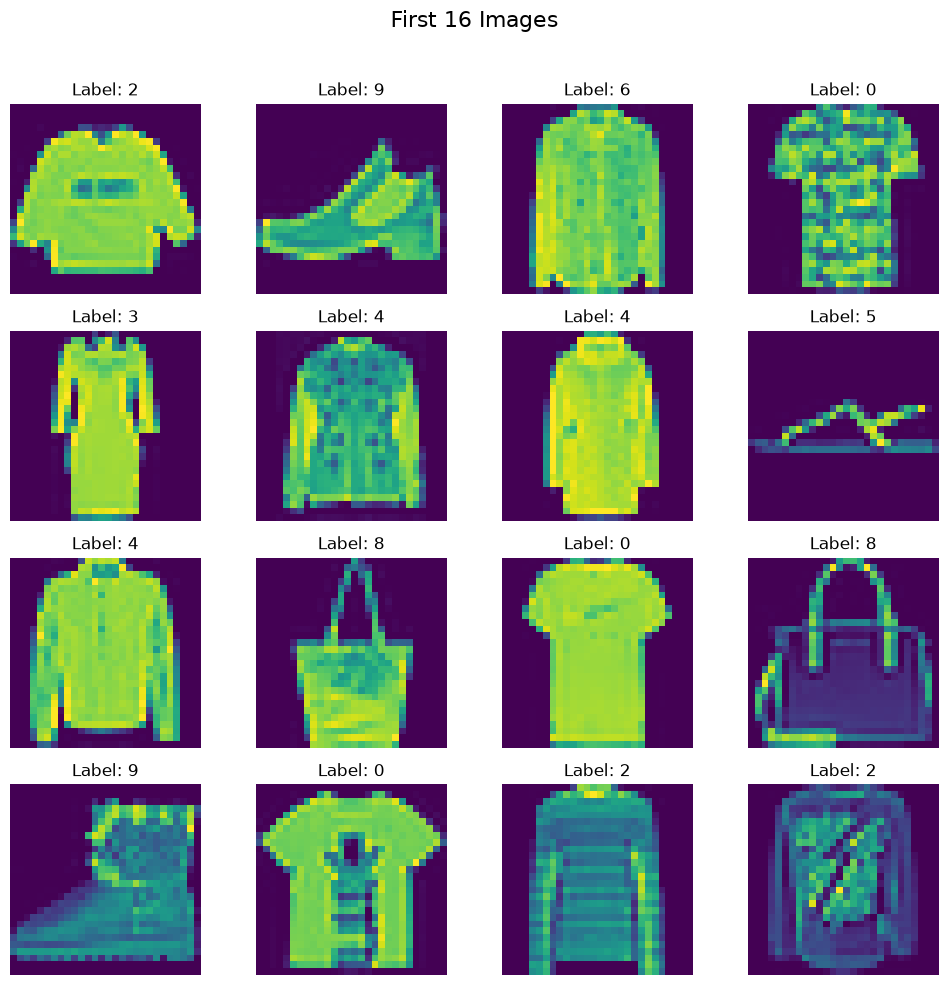

In [37]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}") # show the label

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [38]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# transorformation
from torchvision.transforms import transforms

custom_transofrom = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(244),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

steps:
1: reshape(28,28) -> 2d (maxtrix) -> pil
2: datatype -> (np.unit8)
3: 1D -> 3D
4: tensor -> PIL image
5: resize -> (3,256,256)
6: center crop (3, 224,224)
7: tensor (scale) -> (0,1)
8: normalize

In [51]:
from PIL import Image
import numpy as np
class CustomDataset(Dataset):

    def __init__(self, features, labels, transform):
        self.features = features
        self. labels = labels
        self.transform = transform
    

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        
        #resize to (28,28)
        image = self.features[index].reshape(28,28)

        #change datatype to np.unit8
        image = image.astype(np.uint8)

        # change black and white to color -> (H,W,C) -> (C,H,W)
        image = np.stack([image] * 3, axis=-1)

        #convet array to PIL image
        image = Image.fromarray(image)
 
        #transformation
        image = self.transform(image)

        return image, torch.tensor(self.labels[index], dtype=torch.long)

In [52]:
train_dataset = CustomDataset(X_train, y_train, custom_transofrom)
test_dataset = CustomDataset(X_test, y_test, custom_transofrom)

In [53]:
len(train_dataset)

8000

In [54]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory= True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory= True)

In [55]:
import torchvision.models as models
vgg16 = models.vgg16(pretrained = True)

/Users/bikaschaudharytharu/python/pytorch/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/bikaschaudharytharu/python/pytorch/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [56]:


for param in vgg16.features.parameters():
    param.requires_grad=False


In [57]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512, 10)
)

vgg16.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [58]:
# set learning and ecpoch

epochs = 10
learning_rate = 0.0001


In [59]:


#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.Adam(vgg16.classifier.parameters(), lr= learning_rate)

In [ ]:
#traning loop
for epochs in range(epochs):
    totla_epochs_loss = 0
    for batch_features, batch_lables in train_loader:

        batch_features, batch_lables = batch_features.to(device), batch_lables.to(device)

        # inilalized the model
        outputs = vgg16(batch_features)

        # calcualte loss
        loss = criterion(outputs, batch_lables)

        # no gradation calucalation
        optimizer.zero_grad()

        # calculate the derviative
        loss.backward()
        
        # update the paramaters
        optimizer.step()

        totla_epochs_loss = totla_epochs_loss + loss.item()
    avgerage_loss = totla_epochs_loss / len(train_loader)

    print(f'Epoch: {epochs + 1}, Loss: {avgerage_loss}')


/Users/bikaschaudharytharu/python/pytorch/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
#set model to eval mode
vgg16.eval()

SimpleRNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
#evaluation code

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        output = vgg16(batch_features)

        _,predicted = torch.max(output, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.887


In [ ]:
#evaluation code

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        output = vgg16(batch_features)

        _,predicted = torch.max(output, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9995
